In [4]:
!pip install optuna shap xgboost imbalanced-learn statsmodels -q

In [5]:
pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw/dataset.csv")
df = pd.read_csv(DATA_PATH)

In [16]:
# ================================================================
# PIPELINE BINARY CLASSIFICATION — V3 FINAL
# Prediksi Dropout Mahasiswa: XGBoost + SMOTE-ENN + SHAP
#
# Perubahan utama dari V2 (multiclass):
#   1. Hapus kelas Enrolled → binary: Dropout (1) vs Graduate (0)
#   2. SMOTE-ENN lebih efektif karena hanya 2 kelas
#   3. Optuna optimasi F1-Dropout (binary)
#   4. Evaluasi binary: AUC, F1, Recall, Precision, MCC
#   5. SHAP lebih bersih dan mudah diinterpretasikan
#   6. Threshold optimization untuk recall maksimal
#   7. 10-Fold CV untuk stabilitas
#   8. McNemar test semua baseline
#
# Justifikasi binary:
#   Kelas Enrolled = status sementara (belum final outcome).
#   Sesuai arahan dosen: hanya gunakan data yang sudah
#   memiliki keputusan final (Graduate vs Dropout).
#   Data akademik: semester 1 & 2 → early warning system.
# ================================================================
 
import numpy as np
import pandas as pd
import warnings
import optuna
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import time
 
from sklearn.model_selection import (StratifiedKFold, train_test_split,
                                     cross_val_score, learning_curve)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (f1_score, roc_auc_score, balanced_accuracy_score,
                             cohen_kappa_score, matthews_corrcoef,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score, make_scorer,
                             precision_score, recall_score)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
 
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
 
from xgboost import XGBClassifier
from statsmodels.stats.contingency_tables import mcnemar
 
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
 
SEED = 42
np.random.seed(SEED)
 
log_waktu = {}
 
def catat_waktu(nama, start):
    d = time.time() - start
    log_waktu[nama] = d
    print(f"⏱ [{nama}] selesai dalam {d:.2f} detik")
 
def sep(judul=""):
    print("\n" + "="*65)
    if judul:
        print(f"  {judul}")
        print("="*65)
 


  TAHAP 0: LOAD DATA & FILTER BINARY
Dataset awal   : 4424 baris, 34 fitur
Missing values : 0

=== DISTRIBUSI KELAS AWAL (3 kelas) ===
          Jumlah  Persen (%)
Target                      
Graduate    2209       49.93
Dropout     1421       32.12
Enrolled     794       17.95

⚙️  Menghapus kelas Enrolled (status belum final)...

Dataset setelah filter : 3630 baris

=== DISTRIBUSI KELAS BINARY ===
          Jumlah  Persen (%)
Target                      
Graduate    2209       60.85
Dropout     1421       39.15

Imbalance Ratio: 1.55:1
(jauh lebih seimbang dari 3 kelas sebelumnya)


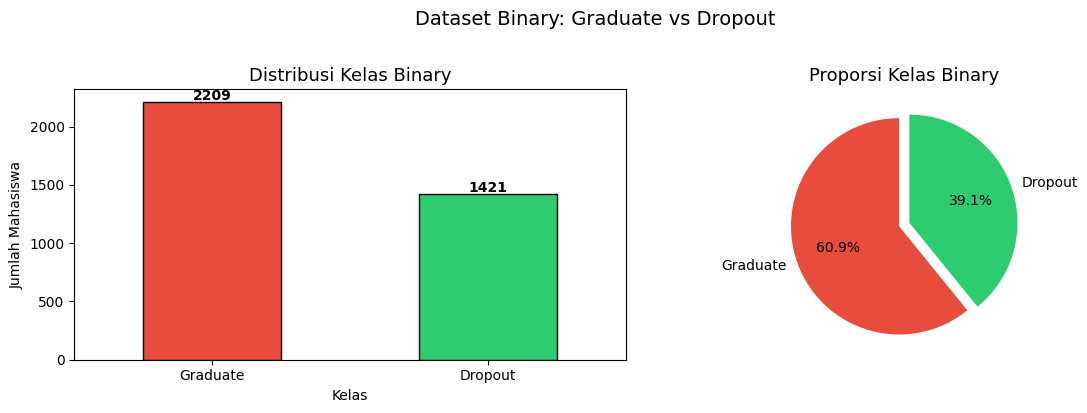

✅ EDA selesai


In [17]:

# ================================================================
# TAHAP 0: LOAD DATA & FILTER BINARY
# ================================================================
sep("TAHAP 0: LOAD DATA & FILTER BINARY")

df = pd.read_csv(DATA_PATH)
print(f"Dataset awal   : {df.shape[0]} baris, {df.shape[1]-1} fitur")
print(f"Missing values : {df.isnull().sum().sum()}")

print("\n=== DISTRIBUSI KELAS AWAL (3 kelas) ===")
dist_awal = df['Target'].value_counts()
dist_pct  = df['Target'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Jumlah': dist_awal, 'Persen (%)': dist_pct.round(2)}))

# --- FILTER: Hapus Enrolled, pertahankan Graduate & Dropout ---
print("\n⚙️  Menghapus kelas Enrolled (status belum final)...")
df_binary = df[df['Target'].isin(['Graduate', 'Dropout'])].copy()
df_binary = df_binary.reset_index(drop=True)

print(f"\nDataset setelah filter : {df_binary.shape[0]} baris")
print("\n=== DISTRIBUSI KELAS BINARY ===")
dist_bin     = df_binary['Target'].value_counts()
dist_bin_pct = df_binary['Target'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Jumlah': dist_bin, 'Persen (%)': dist_bin_pct.round(2)}))
print(f"\nImbalance Ratio: {dist_bin.max()/dist_bin.min():.2f}:1")
print("(jauh lebih seimbang dari 3 kelas sebelumnya)")

# --- Visualisasi distribusi binary ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
warna = ['#e74c3c', '#2ecc71']

dist_bin.plot(kind='bar', ax=axes[0], color=warna, edgecolor='black')
axes[0].set_title("Distribusi Kelas Binary", fontsize=13)
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah Mahasiswa")
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(dist_bin):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(dist_bin, labels=dist_bin.index, autopct='%1.1f%%',
            colors=warna, startangle=90, explode=[0.05, 0.05])
axes[1].set_title("Proporsi Kelas Binary", fontsize=13)
plt.suptitle("Dataset Binary: Graduate vs Dropout", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("v3_distribusi_binary.pdf", dpi=300, bbox_inches='tight')
plt.show()
print("✅ EDA selesai")

In [37]:
print(df.shape)
print(df.columns[:5])

(4424, 35)
Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance'],
      dtype='str')


In [18]:


# ================================================================
# TAHAP 1: ENCODING & PREPROCESSING
# ================================================================
sep("TAHAP 1: ENCODING BINARY")

# Dropout = 1 (kelas positif yang ingin dideteksi)
# Graduate = 0 (kelas negatif)
df_binary['Target_enc'] = df_binary['Target'].map({
    'Dropout': 1,
    'Graduate': 0
})

print("Pemetaan kelas:")
print("  Dropout  → 1 (kelas positif / minority)")
print("  Graduate → 0 (kelas negatif / majority)")

X = df_binary.drop(['Target', 'Target_enc'], axis=1)
y = df_binary['Target_enc']

print(f"\nJumlah fitur : {X.shape[1]}")
print(f"Graduate (0) : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"Dropout  (1) : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")



  TAHAP 1: ENCODING BINARY
Pemetaan kelas:
  Dropout  → 1 (kelas positif / minority)
  Graduate → 0 (kelas negatif / majority)

Jumlah fitur : 34
Graduate (0) : 2209 (60.9%)
Dropout  (1) : 1421 (39.1%)


In [19]:

# ================================================================
# TAHAP 2: STRATIFIED SPLIT 80:20
# ================================================================
sep("TAHAP 2: STRATIFIED SPLIT 80:20")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train : {X_train.shape[0]} sampel")
print(f"Test  : {X_test.shape[0]} sampel")
print(f"\nDistribusi train:")
print(f"  Graduate (0): {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Dropout  (1): {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nDistribusi test:")
print(f"  Graduate (0): {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Dropout  (1): {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")


  TAHAP 2: STRATIFIED SPLIT 80:20
Train : 2904 sampel
Test  : 726 sampel

Distribusi train:
  Graduate (0): 1767 (60.8%)
  Dropout  (1): 1137 (39.2%)

Distribusi test:
  Graduate (0): 442 (60.9%)
  Dropout  (1): 284 (39.1%)


In [20]:

# ================================================================
# TAHAP 3: SCALING
# ================================================================
sep("TAHAP 3: SCALING")

start = time.time()
scaler = StandardScaler()
X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns, index=X_test.index
)
catat_waktu("Scaling", start)


  TAHAP 3: SCALING
⏱ [Scaling] selesai dalam 0.02 detik


In [21]:


# ================================================================
# TAHAP 4: SMOTE-ENN BINARY
#
# Keunggulan binary vs multiclass:
#   - ENN lebih presisi karena hanya 2 kelas
#   - Tidak ada risiko Graduate terpangkas berlebihan
#   - Decision boundary lebih jelas
# ================================================================
sep("TAHAP 4: SMOTE-ENN BINARY")

start = time.time()

n_dropout_train  = (y_train == 1).sum()
n_graduate_train = (y_train == 0).sum()

print(f"Sebelum SMOTE-ENN:")
print(f"  Graduate (0): {n_graduate_train}")
print(f"  Dropout  (1): {n_dropout_train}")

# Target: seimbangkan Dropout ke 90% dari Graduate
target_dropout = int(n_graduate_train * 0.90)

smote = SMOTE(
    k_neighbors=5,
    random_state=SEED,
    sampling_strategy={1: target_dropout}
)
enn = EditedNearestNeighbours(
    n_neighbors=3,
    kind_sel='mode'
)

X_smote, y_smote = smote.fit_resample(X_train_sc, y_train)
X_res, y_res     = enn.fit_resample(X_smote, y_smote)

n_res_grad = (y_res == 0).sum()
n_res_drop = (y_res == 1).sum()
rasio      = n_res_drop / n_res_grad

print(f"\nSetelah SMOTE-ENN:")
print(f"  Graduate (0): {n_res_grad}")
print(f"  Dropout  (1): {n_res_drop}")
print(f"  Rasio        : {rasio:.3f} ({rasio*100:.1f}%)")

status = "✅ Seimbang" if rasio >= 0.80 else "⚠️ Perlu dicek"
print(f"  Status       : {status}")

catat_waktu("SMOTE-ENN Binary", start)



  TAHAP 4: SMOTE-ENN BINARY
Sebelum SMOTE-ENN:
  Graduate (0): 1767
  Dropout  (1): 1137

Setelah SMOTE-ENN:
  Graduate (0): 1577
  Dropout  (1): 1590
  Rasio        : 1.008 (100.8%)
  Status       : ✅ Seimbang
⏱ [SMOTE-ENN Binary] selesai dalam 6.48 detik


In [22]:

# ================================================================
# TAHAP 5: OPTUNA — BINARY F1-DROPOUT
# ================================================================
sep("TAHAP 5: OPTUNA TUNING (Binary F1-Dropout)")

start = time.time()

# Scorer binary: F1 kelas Dropout (pos_label=1)
scorer_f1_dropout = make_scorer(
    f1_score, pos_label=1, average='binary', zero_division=0
)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 700),
        'max_depth':         trial.suggest_int('max_depth', 3, 6),
        'learning_rate':     trial.suggest_float('lr', 0.005, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('col_tree', 0.4, 1.0),
        'colsample_bylevel': trial.suggest_float('col_level', 0.4, 1.0),
        'colsample_bynode':  trial.suggest_float('col_node', 0.4, 1.0),
        'min_child_weight':  trial.suggest_int('min_child', 5, 30),
        'gamma':             trial.suggest_float('gamma', 0.0, 10.0),
        'max_delta_step':    trial.suggest_int('delta_step', 1, 10),
        'reg_alpha':         trial.suggest_float('alpha', 1.0, 30.0, log=True),
        'reg_lambda':        trial.suggest_float('lambda', 1.0, 30.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos', 0.5, 2.0),
        'objective':         'binary:logistic',
        'eval_metric':       'logloss',
        'tree_method':       'hist',
        'random_state':      SEED,
        'use_label_encoder': False,
        'n_jobs':            -1,
    }
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model  = XGBClassifier(**params)
    scores = cross_val_score(
        model, X_res, y_res,
        cv=cv, scoring=scorer_f1_dropout, n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=15, n_warmup_steps=5
    )
)
study.optimize(
    objective, n_trials=200, timeout=7200,
    show_progress_bar=True
)

# Bersihkan nama key hasil suggest_float
rename_map = {
    'lr': 'learning_rate',
    'col_tree': 'colsample_bytree',
    'col_level': 'colsample_bylevel',
    'col_node': 'colsample_bynode',
    'min_child': 'min_child_weight',
    'delta_step': 'max_delta_step',
    'alpha': 'reg_alpha',
    'lambda': 'reg_lambda',
    'scale_pos': 'scale_pos_weight',
}
best_params = {}
for k, v in study.best_params.items():
    best_params[rename_map.get(k, k)] = v

best_params.update({
    'objective':          'binary:logistic',
    'eval_metric':        'logloss',
    'tree_method':        'hist',
    'random_state':       SEED,
    'use_label_encoder':  False,
    'n_jobs':             -1,
})

print("\n=== HYPERPARAMETER FINAL (V3 Binary) ===")
param_order = [
    'n_estimators', 'max_depth', 'learning_rate',
    'subsample', 'colsample_bytree', 'colsample_bylevel',
    'colsample_bynode', 'min_child_weight', 'gamma',
    'max_delta_step', 'reg_alpha', 'reg_lambda', 'scale_pos_weight'
]
for p in param_order:
    if p in best_params:
        v = best_params[p]
        print(f"  {p:<28}: {v:.6f}" if isinstance(v, float)
              else f"  {p:<28}: {v}")

print(f"\nF1-Dropout CV terbaik : {study.best_value:.4f}")
print(f"Trial terbaik         : {study.best_trial.number}")
catat_waktu("Optuna Binary (200 trial)", start)



  TAHAP 5: OPTUNA TUNING (Binary F1-Dropout)


  0%|          | 0/200 [00:00<?, ?it/s]

Best trial: 125. Best value: 0.924068: 100%|██████████| 200/200 [06:27<00:00,  1.94s/it, 387.71/7200 seconds]


=== HYPERPARAMETER FINAL (V3 Binary) ===
  n_estimators                : 642
  max_depth                   : 6
  learning_rate               : 0.095099
  subsample                   : 0.795757
  colsample_bytree            : 0.728146
  colsample_bylevel           : 0.894084
  colsample_bynode            : 0.484281
  min_child_weight            : 8
  gamma                       : 0.721363
  max_delta_step              : 2
  reg_alpha                   : 1.006079
  reg_lambda                  : 3.267091
  scale_pos_weight            : 1.338014

F1-Dropout CV terbaik : 0.9241
Trial terbaik         : 125
⏱ [Optuna Binary (200 trial)] selesai dalam 387.76 detik


In [23]:

# ================================================================
# TAHAP 6: TRAINING MODEL FINAL
# ================================================================
sep("TAHAP 6: TRAINING MODEL FINAL")

start = time.time()
model_final = XGBClassifier(**best_params)
model_final.fit(
    X_res, y_res,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)
catat_waktu("Training XGBoost Binary", start)



  TAHAP 6: TRAINING MODEL FINAL
⏱ [Training XGBoost Binary] selesai dalam 2.20 detik


In [24]:

# ================================================================
# TAHAP 7: PREDIKSI & EVALUASI MODEL UTAMA
# ================================================================
sep("TAHAP 7: EVALUASI MODEL UTAMA (BINARY)")

start = time.time()
y_pred = model_final.predict(X_test_sc)
y_prob = model_final.predict_proba(X_test_sc)[:, 1]

hasil_evaluasi = {
    'Accuracy':          round(accuracy_score(y_test, y_pred), 4),
    'Balanced Accuracy': round(balanced_accuracy_score(y_test, y_pred), 4),
    'F1-Binary':         round(f1_score(y_test, y_pred,
                                        pos_label=1, average='binary'), 4),
    'Precision':         round(precision_score(y_test, y_pred,
                                               pos_label=1, zero_division=0), 4),
    'Recall':            round(recall_score(y_test, y_pred,
                                            pos_label=1, zero_division=0), 4),
    'AUC-ROC':           round(roc_auc_score(y_test, y_prob), 4),
    'Cohen Kappa':       round(cohen_kappa_score(y_test, y_pred), 4),
    'MCC':               round(matthews_corrcoef(y_test, y_pred), 4),
}

print("\n=== HASIL EVALUASI MODEL UTAMA (V3 Binary) ===")
df_eval = pd.DataFrame([hasil_evaluasi]).T.rename(columns={0: 'Score'})
print(df_eval)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test, y_pred,
    target_names=['Graduate (0)', 'Dropout (1)']
))
catat_waktu("Prediksi & Evaluasi", start)


  TAHAP 7: EVALUASI MODEL UTAMA (BINARY)

=== HASIL EVALUASI MODEL UTAMA (V3 Binary) ===
                    Score
Accuracy           0.9022
Balanced Accuracy  0.9071
F1-Binary          0.8815
Precision          0.8381
Recall             0.9296
AUC-ROC            0.9711
Cohen Kappa        0.7986
MCC                0.8017

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Graduate (0)       0.95      0.88      0.92       442
 Dropout (1)       0.84      0.93      0.88       284

    accuracy                           0.90       726
   macro avg       0.89      0.91      0.90       726
weighted avg       0.91      0.90      0.90       726

⏱ [Prediksi & Evaluasi] selesai dalam 0.26 detik



  TAHAP 7.1: LEARNING CURVE


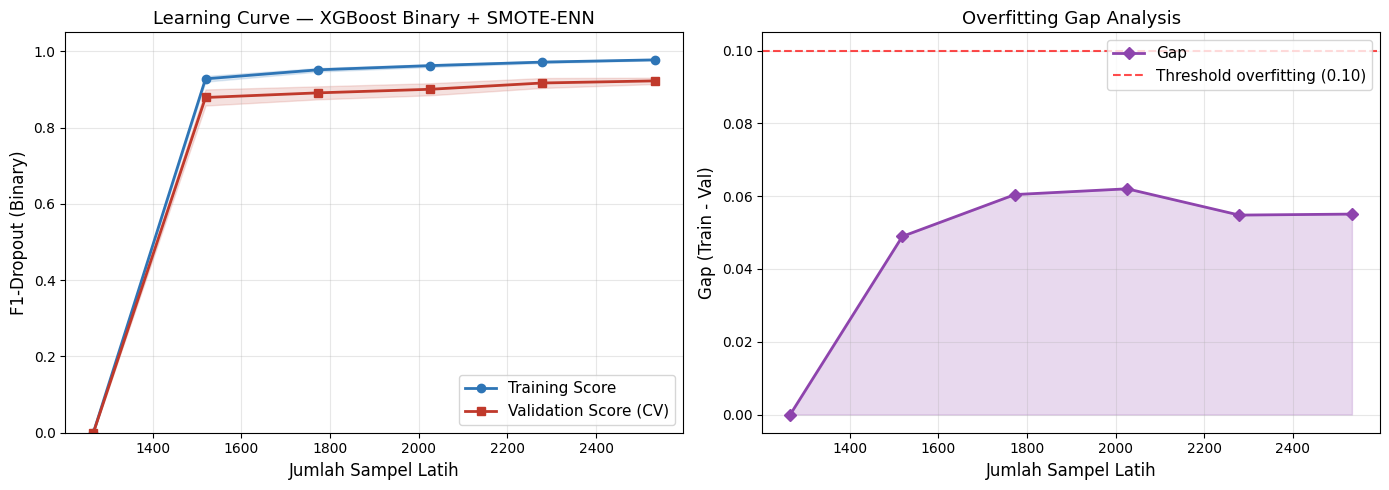


Training Score final  : 0.9778 ± 0.0012
Validation Score final: 0.9227 ± 0.0083
Gap akhir             : 0.0551 → ✅ Tidak overfitting


In [25]:


# ================================================================
# TAHAP 7.1: LEARNING CURVE
# ================================================================
sep("TAHAP 7.1: LEARNING CURVE")

train_sz, tr_sc, val_sc = learning_curve(
    XGBClassifier(**best_params),
    X_res, y_res,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring=scorer_f1_dropout,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_sz, tr_sc.mean(axis=1), 'o-', color='#2E75B6',
             label='Training Score', lw=2)
axes[0].fill_between(train_sz,
    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
    tr_sc.mean(axis=1) + tr_sc.std(axis=1),
    alpha=0.15, color='#2E75B6')
axes[0].plot(train_sz, val_sc.mean(axis=1), 's-', color='#C0392B',
             label='Validation Score (CV)', lw=2)
axes[0].fill_between(train_sz,
    val_sc.mean(axis=1) - val_sc.std(axis=1),
    val_sc.mean(axis=1) + val_sc.std(axis=1),
    alpha=0.15, color='#C0392B')
axes[0].set_xlabel("Jumlah Sampel Latih", fontsize=12)
axes[0].set_ylabel("F1-Dropout (Binary)", fontsize=12)
axes[0].set_title("Learning Curve — XGBoost Binary + SMOTE-ENN", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1.05])

gap = tr_sc.mean(axis=1) - val_sc.mean(axis=1)
axes[1].plot(train_sz, gap, 'D-', color='#8E44AD', lw=2, label='Gap')
axes[1].axhline(y=0.10, color='red', ls='--', alpha=0.7,
                label='Threshold overfitting (0.10)')
axes[1].fill_between(train_sz, 0, gap, alpha=0.2, color='#8E44AD')
axes[1].set_xlabel("Jumlah Sampel Latih", fontsize=12)
axes[1].set_ylabel("Gap (Train - Val)", fontsize=12)
axes[1].set_title("Overfitting Gap Analysis", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("v3_learning_curve.pdf", dpi=300, bbox_inches='tight')
plt.show()

gap_akhir = gap[-1]
status_gap = "✅ Tidak overfitting" if gap_akhir < 0.10 else "⚠️ Masih overfitting"
print(f"\nTraining Score final  : {tr_sc.mean(axis=1)[-1]:.4f} "
      f"± {tr_sc.std(axis=1)[-1]:.4f}")
print(f"Validation Score final: {val_sc.mean(axis=1)[-1]:.4f} "
      f"± {val_sc.std(axis=1)[-1]:.4f}")
print(f"Gap akhir             : {gap_akhir:.4f} → {status_gap}")



  TAHAP 7.2: AUC-ROC CURVE


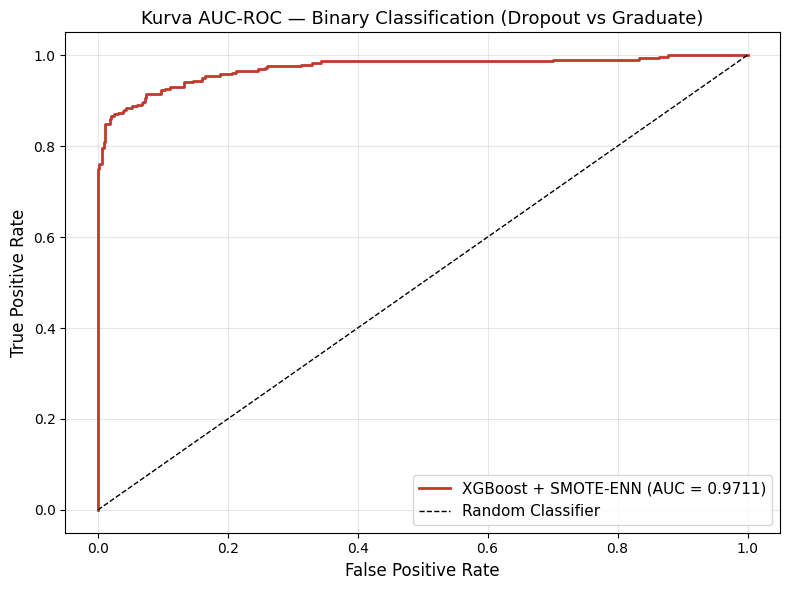

In [26]:

# ================================================================
# TAHAP 7.2: AUC-ROC CURVE
# ================================================================
sep("TAHAP 7.2: AUC-ROC CURVE")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#C0392B', lw=2,
         label=f'XGBoost + SMOTE-ENN (AUC = {auc_score:.4f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("Kurva AUC-ROC — Binary Classification (Dropout vs Graduate)",
          fontsize=13)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("v3_roc_curve.pdf", dpi=300, bbox_inches='tight')
plt.show()



  TAHAP 7.3: THRESHOLD OPTIMIZATION


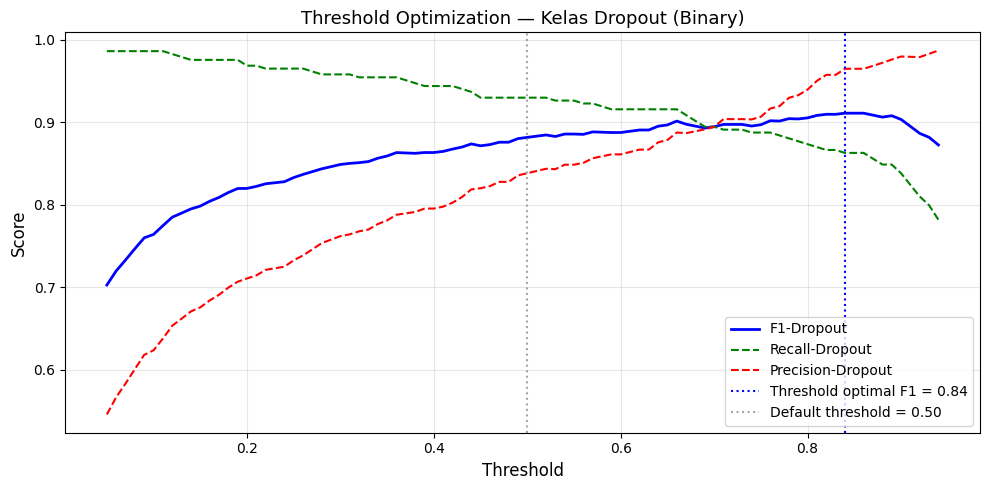


=== PERBANDINGAN THRESHOLD ===
Metrik           Default (0.50)     Optimal (0.84)      Delta
------------------------------------------------------------
Dropout Precision          0.8381             0.9646 +   0.1265
Dropout Recall           0.9296             0.8627   -0.0669
Dropout F1               0.8815             0.9108 +   0.0293


In [27]:

# ================================================================
# TAHAP 7.3: THRESHOLD OPTIMIZATION
# ================================================================
sep("TAHAP 7.3: THRESHOLD OPTIMIZATION")

thresholds  = np.arange(0.05, 0.95, 0.01)
f1_list, rec_list, prec_list = [], [], []

for t in thresholds:
    yp = (y_prob >= t).astype(int)
    f1_list.append(f1_score(y_test, yp, pos_label=1,
                             average='binary', zero_division=0))
    rec_list.append(recall_score(y_test, yp, pos_label=1, zero_division=0))
    prec_list.append(precision_score(y_test, yp, pos_label=1, zero_division=0))

best_idx       = np.argmax(f1_list)
best_threshold = thresholds[best_idx]
best_f1_thresh = f1_list[best_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_list,   'b-',  lw=2, label='F1-Dropout')
ax.plot(thresholds, rec_list,  'g--', lw=1.5, label='Recall-Dropout')
ax.plot(thresholds, prec_list, 'r--', lw=1.5, label='Precision-Dropout')
ax.axvline(x=best_threshold, color='blue', ls=':',
           label=f'Threshold optimal F1 = {best_threshold:.2f}')
ax.axvline(x=0.5, color='gray', ls=':', alpha=0.7,
           label='Default threshold = 0.50')
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Threshold Optimization — Kelas Dropout (Binary)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("v3_threshold_optimization.pdf", dpi=300, bbox_inches='tight')
plt.show()

y_pred_optimal = (y_prob >= best_threshold).astype(int)
print(f"\n=== PERBANDINGAN THRESHOLD ===")
print(f"{'Metrik':<15} {'Default (0.50)':>15} "
      f"{'Optimal ({:.2f})'.format(best_threshold):>18} {'Delta':>10}")
print("-"*60)
for m_name, default_val, optimal_val in [
    ('Precision', precision_score(y_test, y_pred, pos_label=1, zero_division=0),
                  precision_score(y_test, y_pred_optimal, pos_label=1, zero_division=0)),
    ('Recall',    recall_score(y_test, y_pred, pos_label=1, zero_division=0),
                  recall_score(y_test, y_pred_optimal, pos_label=1, zero_division=0)),
    ('F1',        f1_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0),
                  f1_score(y_test, y_pred_optimal, pos_label=1, average='binary', zero_division=0)),
]:
    delta = optimal_val - default_val
    sign  = "+" if delta >= 0 else ""
    print(f"{'Dropout ' + m_name:<15} {default_val:>15.4f} "
          f"{optimal_val:>18.4f} {sign}{delta:>9.4f}")



  TAHAP 8: PERBANDINGAN SEMUA MODEL (BINARY)
✅ Decision Tree selesai
✅ Logistic Regression selesai
✅ Random Forest selesai
✅ XGBoost (Baseline) selesai
✅ XGBoost + SMOTE-ENN (Proposed) selesai

=== TABEL PERBANDINGAN MODEL (RQ1) ===
                         Model  Accuracy  F1-Dropout  Precision  Recall  AUC-ROC  Balanced Acc  Cohen Kappa    MCC
                 Decision Tree    0.8526      0.8171     0.7940  0.8415   0.8506        0.8506       0.6939 0.6947
           Logistic Regression    0.9284      0.9107     0.8893  0.9331   0.9731        0.9292       0.8509 0.8516
                 Random Forest    0.9270      0.9035     0.9358  0.8732   0.9695        0.9174       0.8449 0.8462
            XGBoost (Baseline)    0.9284      0.9081     0.9113  0.9049   0.9719        0.9242       0.8494 0.8495
XGBoost + SMOTE-ENN (Proposed)    0.9022      0.8815     0.8381  0.9296   0.9711        0.9071       0.7986 0.8017

=== MODEL TERBAIK PER METRIK ===
  F1-Dropout     : Logistic Regression (0.

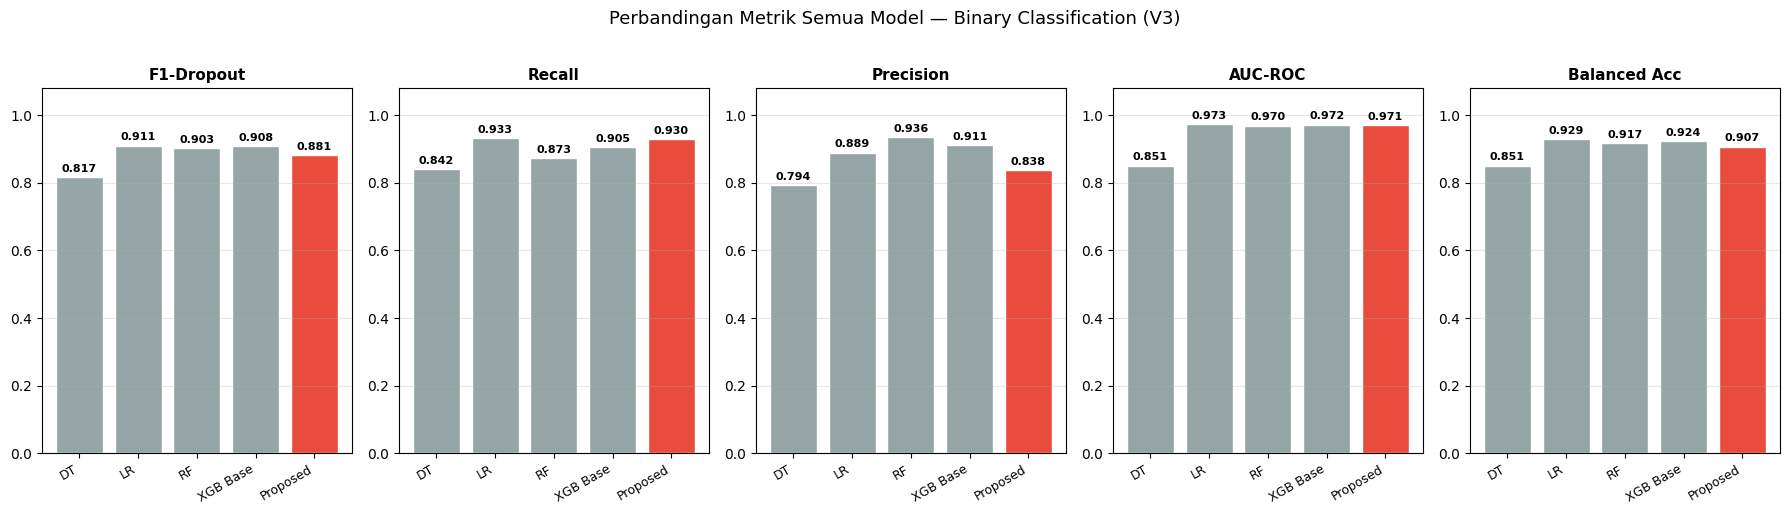

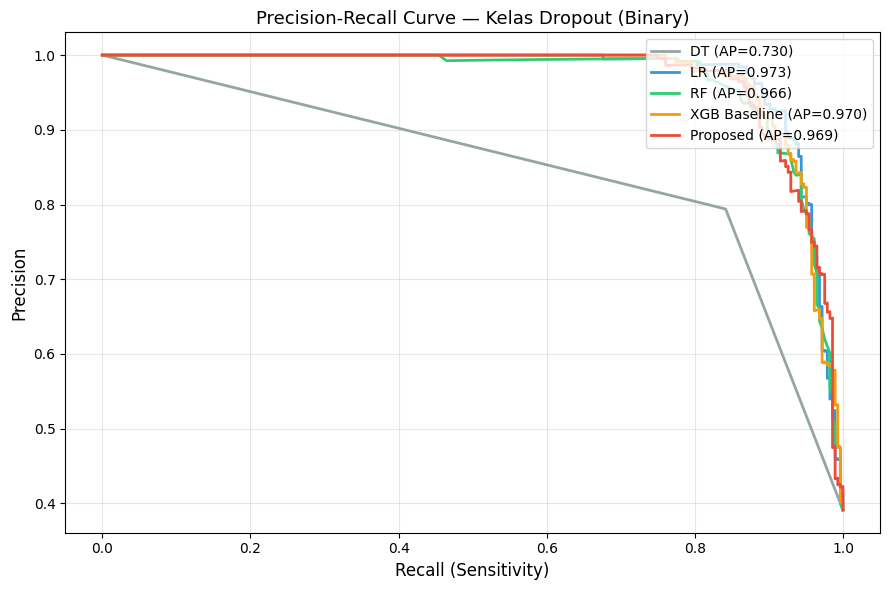

In [29]:

# ================================================================
# TAHAP 8: PERBANDINGAN SEMUA MODEL
# ================================================================
sep("TAHAP 8: PERBANDINGAN SEMUA MODEL (BINARY)")

semua_model = {
    'Decision Tree':
        DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
    'Logistic Regression':
        LogisticRegression(class_weight='balanced',
                           max_iter=1000, random_state=SEED),
    'Random Forest':
        RandomForestClassifier(class_weight='balanced',
                               n_estimators=100, random_state=SEED),
    'XGBoost (Baseline)':
        XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                      random_state=SEED, use_label_encoder=False,
                      eval_metric='logloss', objective='binary:logistic'),
    'XGBoost + SMOTE-ENN (Proposed)': model_final
}

prediksi_semua = {}
prob_semua     = {}
hasil_semua    = []

for nama, mdl in semua_model.items():
    t0 = time.time()
    if nama != 'XGBoost + SMOTE-ENN (Proposed)':
        mdl.fit(X_train_sc, y_train)

    yp_iter   = mdl.predict(X_test_sc)
    ypr_iter  = mdl.predict_proba(X_test_sc)[:, 1]
    prediksi_semua[nama] = yp_iter
    prob_semua[nama]     = ypr_iter

    hasil_semua.append({
        'Model'      : nama,
        'Accuracy'   : round(accuracy_score(y_test, yp_iter), 4),
        'F1-Dropout' : round(f1_score(y_test, yp_iter,
                                       pos_label=1, average='binary'), 4),
        'Precision'  : round(precision_score(y_test, yp_iter,
                                              pos_label=1, zero_division=0), 4),
        'Recall'     : round(recall_score(y_test, yp_iter,
                                           pos_label=1, zero_division=0), 4),
        'AUC-ROC'    : round(roc_auc_score(y_test, ypr_iter), 4),
        'Balanced Acc': round(balanced_accuracy_score(y_test, yp_iter), 4),
        'Cohen Kappa': round(cohen_kappa_score(y_test, yp_iter), 4),
        'MCC'        : round(matthews_corrcoef(y_test, yp_iter), 4),
        'Waktu (s)'  : round(time.time() - t0, 2)
    })
    print(f"✅ {nama} selesai")

df_hasil = pd.DataFrame(hasil_semua)

print("\n=== TABEL PERBANDINGAN MODEL (RQ1) ===")
kolom = ['Model', 'Accuracy', 'F1-Dropout', 'Precision',
         'Recall', 'AUC-ROC', 'Balanced Acc', 'Cohen Kappa', 'MCC']
print(df_hasil[kolom].to_string(index=False))

print("\n=== MODEL TERBAIK PER METRIK ===")
for col in ['F1-Dropout', 'Recall', 'AUC-ROC', 'Balanced Acc',
            'Cohen Kappa', 'MCC']:
    bi  = df_hasil[col].idxmax()
    bm  = df_hasil.loc[bi, 'Model']
    bv  = df_hasil.loc[bi, col]
    print(f"  {col:<15}: {bm} ({bv})")

# --- Bar chart perbandingan ---
metrik_plot  = ['F1-Dropout', 'Recall', 'Precision', 'AUC-ROC', 'Balanced Acc']
model_labels = [m.replace('XGBoost + SMOTE-ENN (Proposed)', 'Proposed')
                 .replace('XGBoost (Baseline)', 'XGB Base')
                 .replace('Logistic Regression', 'LR')
                 .replace('Decision Tree', 'DT')
                 .replace('Random Forest', 'RF')
                for m in df_hasil['Model']]
warna_bar = ['#95a5a6', '#95a5a6', '#95a5a6', '#95a5a6', '#e74c3c']

fig, axes = plt.subplots(1, len(metrik_plot), figsize=(18, 5))
for ax, metrik in zip(axes, metrik_plot):
    vals = df_hasil[metrik].values
    bars = ax.bar(model_labels, vals, color=warna_bar, edgecolor='white')
    ax.set_title(metrik, fontsize=11, fontweight='bold')
    ax.set_ylim([0, 1.08])
    ax.set_xticklabels(model_labels, rotation=30, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

plt.suptitle("Perbandingan Metrik Semua Model — Binary Classification (V3)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("v3_perbandingan_metrik.pdf", dpi=300, bbox_inches='tight')
plt.show()

# --- Precision-Recall Curve ---
fig, ax = plt.subplots(figsize=(9, 6))
warna_pr = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12', '#e74c3c']
label_map = {
    'Decision Tree': 'DT',
    'Logistic Regression': 'LR',
    'Random Forest': 'RF',
    'XGBoost (Baseline)': 'XGB Baseline',
    'XGBoost + SMOTE-ENN (Proposed)': 'Proposed'
}
for (nama, prob), warna_ in zip(prob_semua.items(), warna_pr):
    prec_c, rec_c, _ = precision_recall_curve(y_test, prob, pos_label=1)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec_c, prec_c, color=warna_, lw=2,
            label=f'{label_map[nama]} (AP={ap:.3f})')

ax.set_xlabel("Recall (Sensitivity)", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve — Kelas Dropout (Binary)", fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("v3_precision_recall_curve.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [30]:

# ================================================================
# TAHAP 9: UJI McNEMAR
# ================================================================
sep("TAHAP 9: UJI McNEMAR (BINARY)")

nama_proposed = 'XGBoost + SMOTE-ENN (Proposed)'
pred_proposed = prediksi_semua[nama_proposed]
hasil_mcnemar = []

for nama, pred in prediksi_semua.items():
    if nama == nama_proposed:
        continue
    b_prop = (pred_proposed == y_test.values).astype(int)
    b_base = (pred == y_test.values).astype(int)
    b = np.sum((b_prop==1) & (b_base==0))
    c = np.sum((b_prop==0) & (b_base==1))
    tabel  = [[0, b], [c, 0]]
    hasil  = mcnemar(tabel, exact=(b+c < 25))
    signif = "✅ Signifikan (p<0.05)" if hasil.pvalue < 0.05 \
             else "❌ Tidak Signifikan"
    hasil_mcnemar.append({
        'Perbandingan'   : f"Proposed vs {nama}",
        'b'              : b,
        'c'              : c,
        'p-value'        : round(hasil.pvalue, 4),
        'Kesimpulan'     : signif
    })
    print(f"  Proposed vs {nama:30s}: "
          f"p={hasil.pvalue:.4f} → {signif}")

df_mcnemar = pd.DataFrame(hasil_mcnemar)
print("\n=== TABEL McNEMAR LENGKAP ===")
print(df_mcnemar.to_string(index=False))


  TAHAP 9: UJI McNEMAR (BINARY)
  Proposed vs Decision Tree                 : p=0.0002 → ✅ Signifikan (p<0.05)
  Proposed vs Logistic Regression           : p=0.0101 → ✅ Signifikan (p<0.05)
  Proposed vs Random Forest                 : p=0.0256 → ✅ Signifikan (p<0.05)
  Proposed vs XGBoost (Baseline)            : p=0.0061 → ✅ Signifikan (p<0.05)

=== TABEL McNEMAR LENGKAP ===
                   Perbandingan  b  c  p-value            Kesimpulan
      Proposed vs Decision Tree 63 27   0.0002 ✅ Signifikan (p<0.05)
Proposed vs Logistic Regression 15 34   0.0101 ✅ Signifikan (p<0.05)
      Proposed vs Random Forest 20 38   0.0256 ✅ Signifikan (p<0.05)
 Proposed vs XGBoost (Baseline) 12 31   0.0061 ✅ Signifikan (p<0.05)



  TAHAP 10: CONFUSION MATRIX


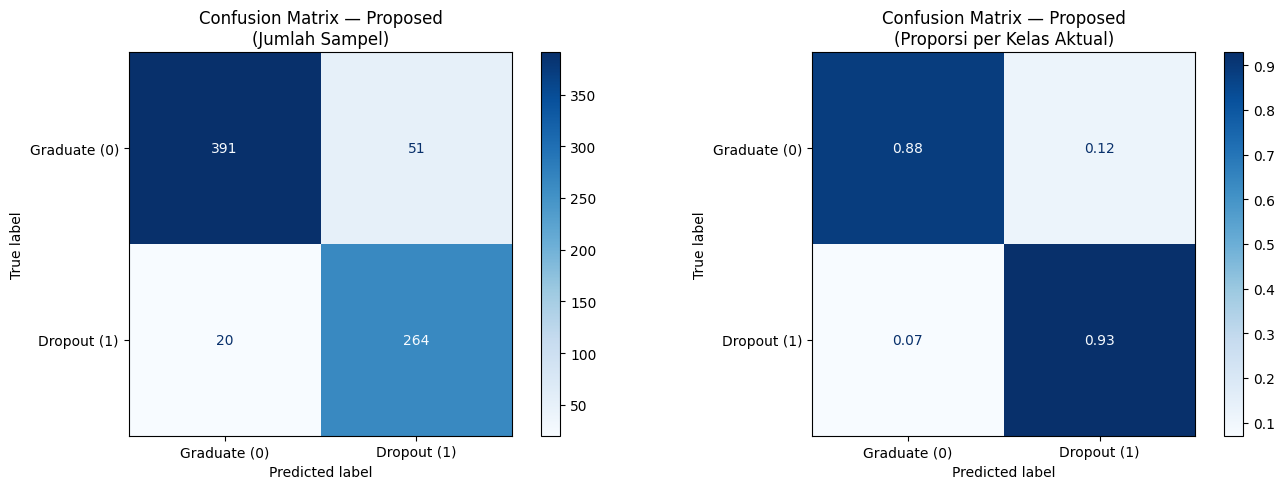


Analisis Confusion Matrix — Kelas Dropout:
  TP (Dropout benar diprediksi Dropout) : 264
  FP (Graduate salah diprediksi Dropout): 51
  FN (Dropout salah diprediksi Graduate): 20
  TN (Graduate benar diprediksi Graduate): 391

  Precision : 0.8381
  Recall    : 0.9296
  F1-Score  : 0.8815

  Interpretasi:
  → Model berhasil mendeteksi 264 dari 284 mahasiswa dropout yang sebenarnya
  → 20 mahasiswa dropout TIDAK terdeteksi (False Negative)
  → 51 mahasiswa Graduate salah diklasifikasi sebagai Dropout


In [31]:


# ================================================================
# TAHAP 10: CONFUSION MATRIX
# ================================================================
sep("TAHAP 10: CONFUSION MATRIX")

label_names = ['Graduate (0)', 'Dropout (1)']
cm          = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=label_names).plot(
    ax=axes[0], cmap='Blues', colorbar=True, values_format='d'
)
axes[0].set_title("Confusion Matrix — Proposed\n(Jumlah Sampel)", fontsize=12)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
ConfusionMatrixDisplay(cm_norm, display_labels=label_names).plot(
    ax=axes[1], cmap='Blues', colorbar=True, values_format='.2f'
)
axes[1].set_title("Confusion Matrix — Proposed\n(Proporsi per Kelas Aktual)",
                   fontsize=12)

plt.tight_layout()
plt.savefig("v3_confusion_matrix.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Analisis TP FP FN TN
TP = cm[1,1]; FP = cm[0,1]; FN = cm[1,0]; TN = cm[0,0]
print(f"\nAnalisis Confusion Matrix — Kelas Dropout:")
print(f"  TP (Dropout benar diprediksi Dropout) : {TP}")
print(f"  FP (Graduate salah diprediksi Dropout): {FP}")
print(f"  FN (Dropout salah diprediksi Graduate): {FN}")
print(f"  TN (Graduate benar diprediksi Graduate): {TN}")
print(f"\n  Precision : {TP/(TP+FP):.4f}")
print(f"  Recall    : {TP/(TP+FN):.4f}")
print(f"  F1-Score  : {2*TP/(2*TP+FP+FN):.4f}")
print(f"\n  Interpretasi:")
print(f"  → Model berhasil mendeteksi {TP} dari {TP+FN} "
      f"mahasiswa dropout yang sebenarnya")
print(f"  → {FN} mahasiswa dropout TIDAK terdeteksi (False Negative)")
print(f"  → {FP} mahasiswa Graduate salah diklasifikasi sebagai Dropout")


  TAHAP 11: ANALISIS SHAP (BINARY)


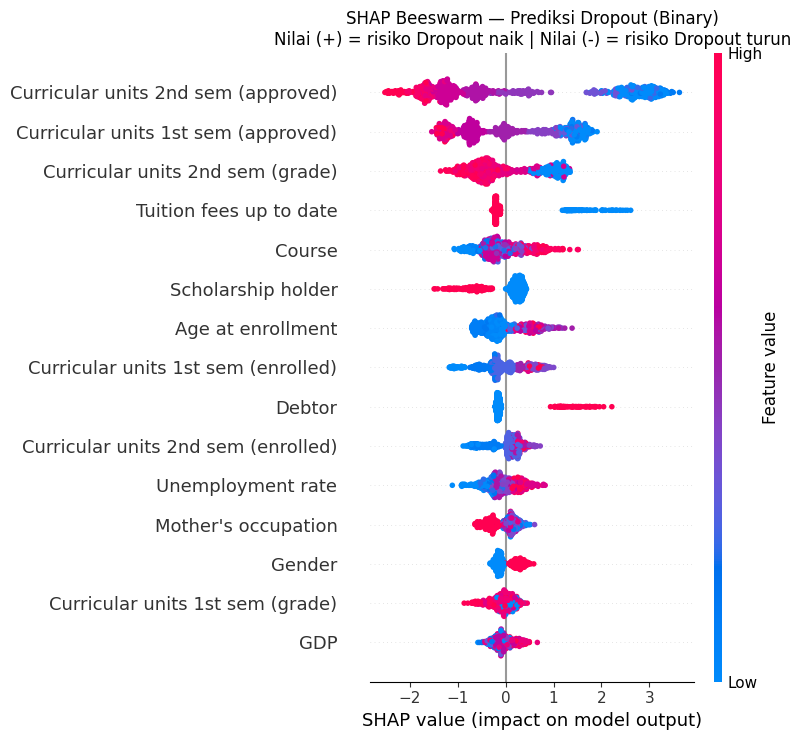

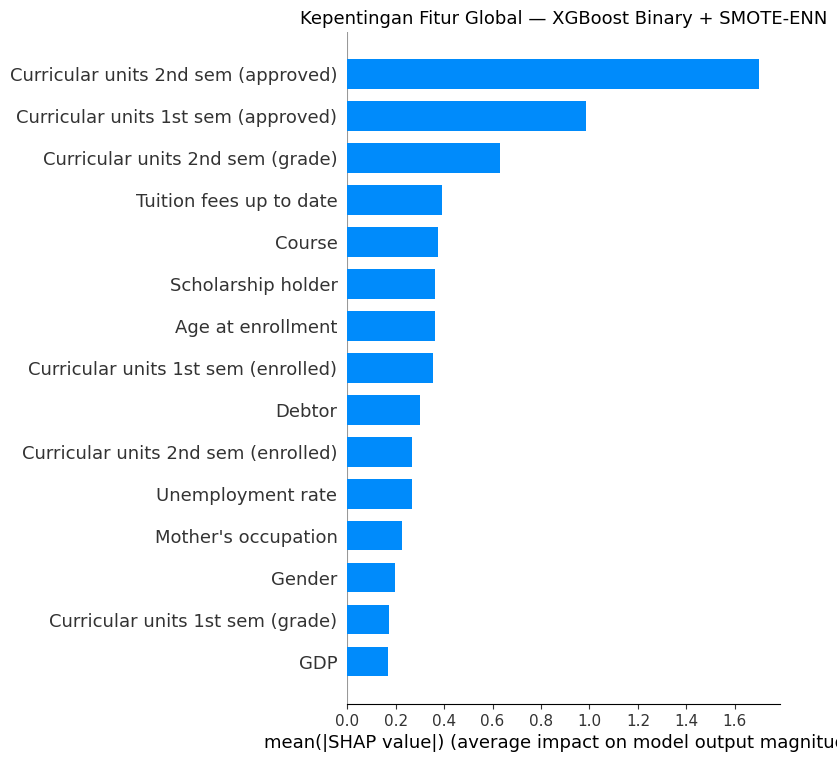


=== TOP 10 FITUR SHAP — Binary Dropout ===
                              Fitur  Mean |SHAP|  Mean SHAP                 Arah
Curricular units 2nd sem (approved)       1.7013     0.2389  Naik risiko Dropout
Curricular units 1st sem (approved)       0.9838     0.0939  Naik risiko Dropout
   Curricular units 2nd sem (grade)       0.6326    -0.0237 Turun risiko Dropout
            Tuition fees up to date       0.3904     0.0681  Naik risiko Dropout
                             Course       0.3759    -0.0377 Turun risiko Dropout
                 Scholarship holder       0.3639     0.0218  Naik risiko Dropout
                  Age at enrollment       0.3611    -0.0483 Turun risiko Dropout
Curricular units 1st sem (enrolled)       0.3561    -0.0143 Turun risiko Dropout
                             Debtor       0.3000     0.0258  Naik risiko Dropout
Curricular units 2nd sem (enrolled)       0.2686     0.0326  Naik risiko Dropout

=== SHAP DEPENDENCE PLOT (Top 3 Fitur) ===


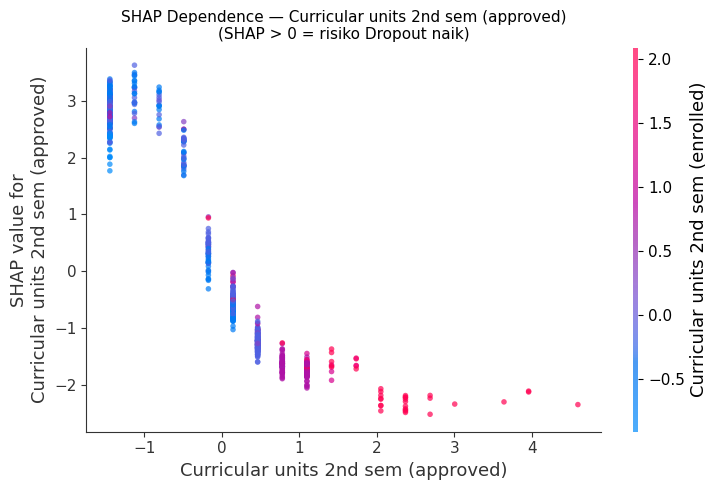

  ✅ Curricular units 2nd sem (approved)


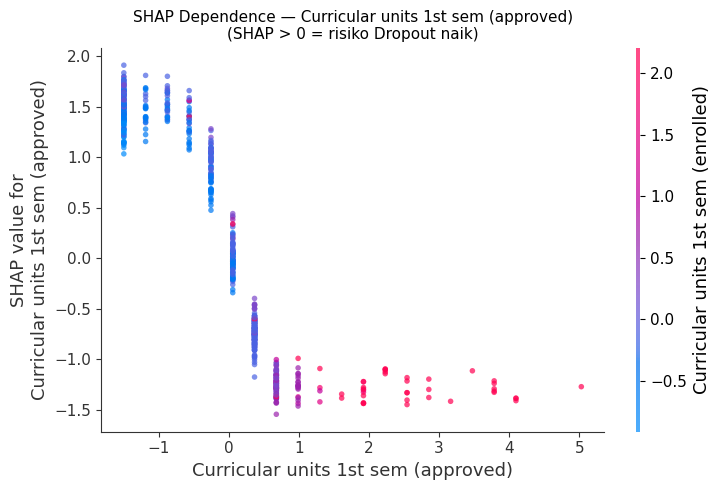

  ✅ Curricular units 1st sem (approved)


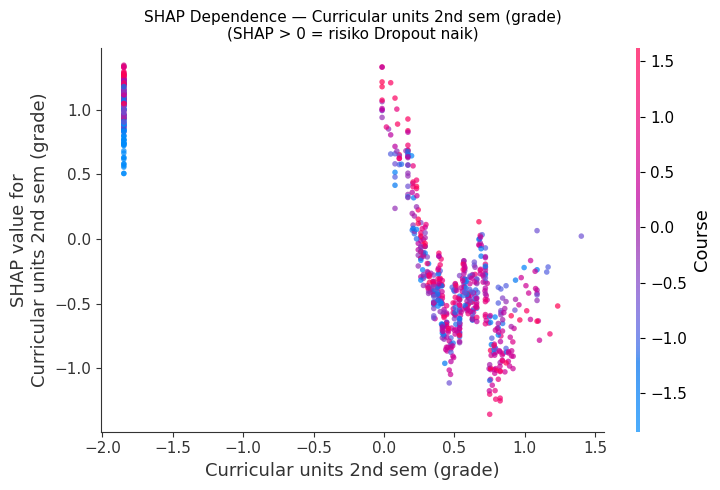

  ✅ Curricular units 2nd sem (grade)


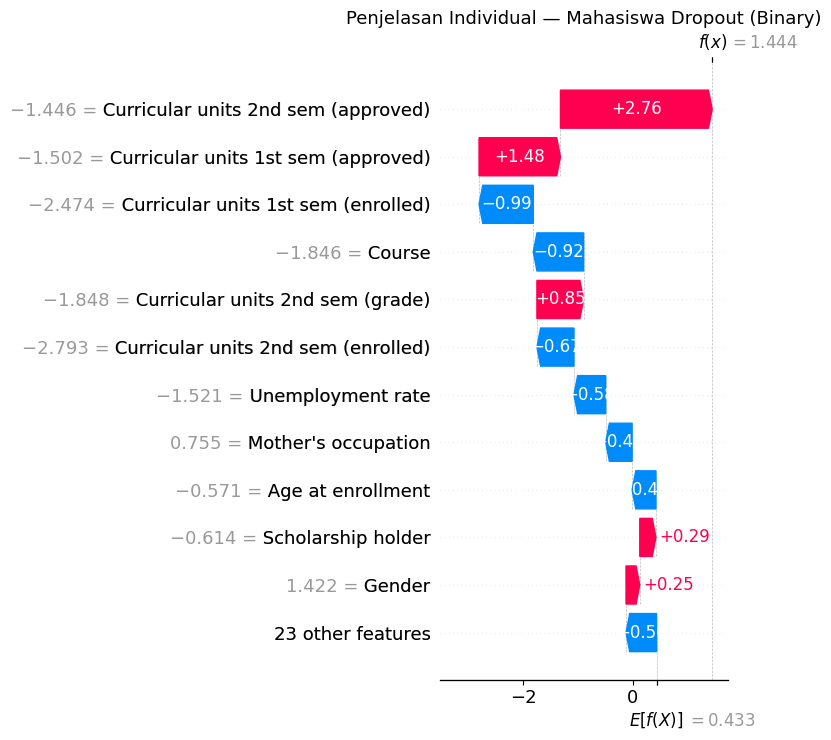

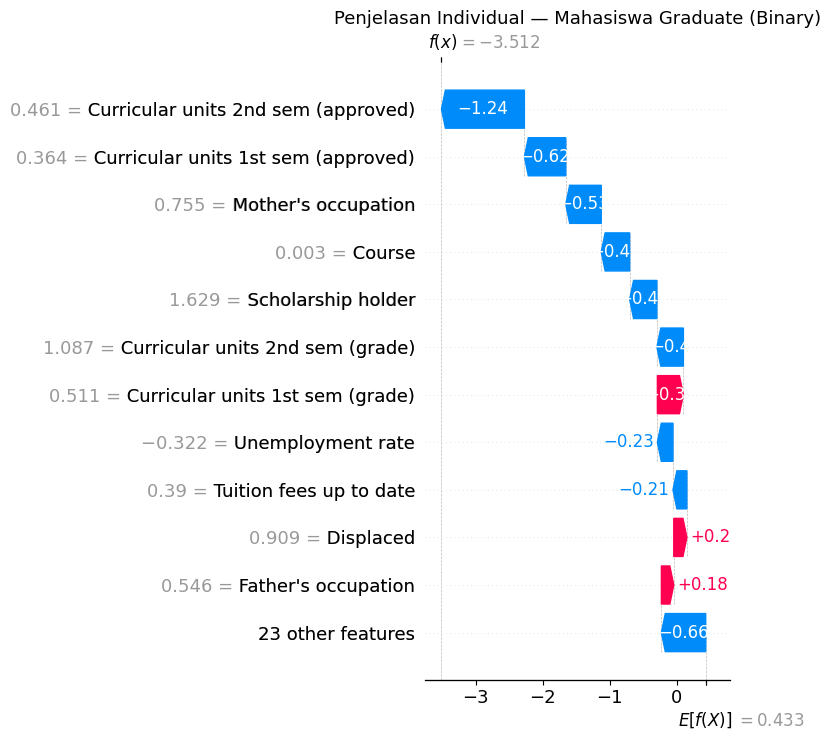

⏱ [SHAP Analysis Binary] selesai dalam 18.26 detik


In [32]:


# ================================================================
# TAHAP 11: ANALISIS SHAP (BINARY)
# ================================================================
sep("TAHAP 11: ANALISIS SHAP (BINARY)")

start = time.time()

explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test_sc)

# Untuk binary XGBoost, shap_values shape: (n_samples, n_features)
# Nilai positif = mendorong ke Dropout, negatif = mendorong ke Graduate

# --- 11A: Beeswarm plot ---
shap.summary_plot(
    shap_values, X_test_sc,
    plot_type='dot', max_display=15, show=False
)
plt.title("SHAP Beeswarm — Prediksi Dropout (Binary)\n"
          "Nilai (+) = risiko Dropout naik | Nilai (-) = risiko Dropout turun",
          fontsize=12)
plt.tight_layout()
plt.savefig("v3_shap_beeswarm.pdf", dpi=300, bbox_inches='tight')
plt.show()


# --- 11B: Bar chart global ---
shap.summary_plot(
    shap_values, X_test_sc,
    plot_type='bar', max_display=15, show=False
)
plt.title("Kepentingan Fitur Global — XGBoost Binary + SMOTE-ENN",
          fontsize=13)
plt.savefig("v3_shap_global_bar.pdf", dpi=300, bbox_inches='tight')
plt.show()

# --- 11C: Top 10 fitur dengan arah dan interpretasi ---
mean_abs  = np.abs(shap_values).mean(axis=0)
mean_dir  = shap_values.mean(axis=0)

df_shap = pd.DataFrame({
    'Fitur'         : X_test_sc.columns,
    'Mean |SHAP|'   : mean_abs.round(4),
    'Mean SHAP'     : mean_dir.round(4),
    'Arah'          : ['Naik risiko Dropout' if d > 0
                        else 'Turun risiko Dropout'
                        for d in mean_dir],
}).sort_values('Mean |SHAP|', ascending=False).head(10)

print("\n=== TOP 10 FITUR SHAP — Binary Dropout ===")
print(df_shap.to_string(index=False))


# --- 11D: Dependence plot 3 fitur teratas ---
top3 = df_shap['Fitur'].head(3).tolist()
print(f"\n=== SHAP DEPENDENCE PLOT (Top 3 Fitur) ===")
for fitur in top3:
    shap.dependence_plot(
        fitur, shap_values, X_test_sc,
        interaction_index='auto', show=False, alpha=0.7
    )
    plt.title(f"SHAP Dependence — {fitur}\n"
              f"(SHAP > 0 = risiko Dropout naik)", fontsize=11)
    plt.tight_layout()
    fn = fitur.replace(' ', '_').replace('(','').replace(')','')[:30]
    plt.savefig(f"v3_shap_dep_{fn}.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"  ✅ {fitur}")


# --- 11E: Waterfall individual — Dropout yang benar diprediksi ---
idx_dropout_benar = np.where((y_test.values == 1) & (y_pred == 1))[0]
if len(idx_dropout_benar) > 0:
    idx_s = idx_dropout_benar[0]
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx_s],
            base_values   = explainer.expected_value,
            data          = X_test_sc.iloc[idx_s].values,
            feature_names = X_test_sc.columns.tolist()
        ),
        max_display=12, show=False
    )
    plt.title("Penjelasan Individual — Mahasiswa Dropout (Binary)", fontsize=13)
    plt.tight_layout()
    plt.savefig("v3_shap_waterfall_dropout.pdf", dpi=300, bbox_inches='tight')
    plt.show()


# --- 11F: Waterfall individual — Graduate yang benar diprediksi ---
idx_grad_benar = np.where((y_test.values == 0) & (y_pred == 0))[0]
if len(idx_grad_benar) > 0:
    idx_g = idx_grad_benar[0]
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[idx_g],
            base_values   = explainer.expected_value,
            data          = X_test_sc.iloc[idx_g].values,
            feature_names = X_test_sc.columns.tolist()
        ),
        max_display=12, show=False
    )
    plt.title("Penjelasan Individual — Mahasiswa Graduate (Binary)", fontsize=13)
    plt.tight_layout()
    plt.savefig("v3_shap_waterfall_graduate.pdf", dpi=300, bbox_inches='tight')
    plt.show()

catat_waktu("SHAP Analysis Binary", start)


In [34]:

# ================================================================
# TAHAP 12: STABILITAS — 10-FOLD CV
# ================================================================
sep("TAHAP 12: STABILITAS 10-FOLD CV")

start = time.time()
cv10  = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

metrik_cv = {
    'F1-Dropout':    scorer_f1_dropout,
     'AUC-ROC':       'roc_auc',
    'Balanced Acc':  make_scorer(balanced_accuracy_score),
    'MCC':           make_scorer(matthews_corrcoef),
}

print("Menjalankan 10-Fold CV pada model final...")
hasil_cv = {}
for nama_m, scorer in metrik_cv.items():
    try:
        scores = cross_val_score(
            XGBClassifier(**best_params),
            X_res, y_res, cv=cv10, scoring=scorer, n_jobs=-1
        )
        hasil_cv[nama_m] = {
            'Mean': round(scores.mean(), 4),
            'Std' : round(scores.std(), 4),
            'Min' : round(scores.min(), 4),
            'Max' : round(scores.max(), 4)
        }
        print(f"  {nama_m:<15}: {scores.mean():.4f} ± {scores.std():.4f}")
    except Exception as e:
        print(f"  {nama_m}: Error — {e}")

df_cv = pd.DataFrame(hasil_cv).T
print("\n=== TABEL STABILITAS 10-FOLD CV ===")
print(df_cv)
catat_waktu("10-Fold CV Stability", start)


  TAHAP 12: STABILITAS 10-FOLD CV
Menjalankan 10-Fold CV pada model final...
  F1-Dropout     : 0.9206 ± 0.0103
  AUC-ROC        : 0.9711 ± 0.0128
  Balanced Acc   : 0.9214 ± 0.0100
  MCC            : 0.8436 ± 0.0200

=== TABEL STABILITAS 10-FOLD CV ===
                Mean     Std     Min     Max
F1-Dropout    0.9206  0.0103  0.8990  0.9367
AUC-ROC       0.9711  0.0128  0.9408  0.9859
Balanced Acc  0.9214  0.0100  0.9023  0.9369
MCC           0.8436  0.0200  0.8064  0.8739
⏱ [10-Fold CV Stability] selesai dalam 16.40 detik


In [35]:

# ================================================================
# RINGKASAN WAKTU
# ================================================================
sep("RINGKASAN WAKTU EKSEKUSI V3")

total = sum(log_waktu.values())
df_w  = pd.DataFrame([
    {'Tahap': t, 'Detik': f"{d:.2f}", 'Menit': f"{d/60:.2f}"}
    for t, d in log_waktu.items()
])
df_w.loc[len(df_w)] = {'Tahap': 'TOTAL',
                        'Detik': f"{total:.2f}",
                        'Menit': f"{total/60:.2f}"}
print(df_w.to_string(index=False))



  RINGKASAN WAKTU EKSEKUSI V3
                    Tahap  Detik Menit
                  Scaling   0.02  0.00
         SMOTE-ENN Binary   6.48  0.11
Optuna Binary (200 trial) 387.76  6.46
  Training XGBoost Binary   2.20  0.04
      Prediksi & Evaluasi   0.26  0.00
     SHAP Analysis Binary  18.26  0.30
     10-Fold CV Stability  16.40  0.27
                    TOTAL 431.38  7.19


In [36]:

# ================================================================
# RINGKASAN AKHIR — JAWABAN RQ1 & RQ2
# ================================================================
sep("RINGKASAN UNTUK PAPER — RQ1 & RQ2")

proposed = df_hasil[
    df_hasil['Model'] == 'XGBoost + SMOTE-ENN (Proposed)'
].iloc[0]
baseline = df_hasil[
    df_hasil['Model'] == 'XGBoost (Baseline)'
].iloc[0]

print("\n[RQ1] Peningkatan performa deteksi kelas Dropout (Binary):")
for col in ['F1-Dropout', 'Recall', 'Precision', 'AUC-ROC',
            'Balanced Acc', 'MCC']:
    delta = proposed[col] - baseline[col]
    sign  = "+" if delta >= 0 else ""
    trend = "⬆" if delta >= 0 else "⬇"
    print(f"  {col:<15}: Baseline={baseline[col]:.4f} → "
          f"Proposed={proposed[col]:.4f} ({sign}{delta:.4f}) {trend}")

print(f"\n[RQ1] Threshold Optimal: {best_threshold:.2f}")
print(f"  F1-Dropout default  (0.50): "
      f"{f1_score(y_test, y_pred, pos_label=1, average='binary'):.4f}")
print(f"  F1-Dropout optimal ({best_threshold:.2f}): {best_f1_thresh:.4f}")

print(f"\n[RQ1] Uji McNemar:")
for row in hasil_mcnemar:
    print(f"  {row['Perbandingan']}: p={row['p-value']} → {row['Kesimpulan']}")

print(f"\n[RQ2] Top 5 Fitur SHAP — Binary Dropout:")
print(df_shap[['Fitur','Mean |SHAP|','Arah']].head(5).to_string(index=False))

print(f"\n[KONTEKS EARLY WARNING]")
print(f"  Data yang digunakan: fitur demografis + akademik semester 1 & 2")
print(f"  Waktu prediksi: akhir semester 2 (sebelum dropout terjadi)")
print(f"  Manfaat praktis: intervensi dapat dilakukan pada semester 3")

print("\n✅ Pipeline V3 Binary selesai tanpa error.")
print("\nFile PDF yang dihasilkan:")
for f in [
    "v3_distribusi_binary.pdf",
    "v3_learning_curve.pdf",
    "v3_roc_curve.pdf",
    "v3_threshold_optimization.pdf",
    "v3_perbandingan_metrik.pdf",
    "v3_precision_recall_curve.pdf",
    "v3_confusion_matrix.pdf",
    "v3_shap_beeswarm.pdf",
    "v3_shap_global_bar.pdf",
    "v3_shap_dep_[top3].pdf",
    "v3_shap_waterfall_dropout.pdf",
    "v3_shap_waterfall_graduate.pdf",
]:
    print(f"  → {f}")


  RINGKASAN UNTUK PAPER — RQ1 & RQ2

[RQ1] Peningkatan performa deteksi kelas Dropout (Binary):
  F1-Dropout     : Baseline=0.9081 → Proposed=0.8815 (-0.0266) ⬇
  Recall         : Baseline=0.9049 → Proposed=0.9296 (+0.0247) ⬆
  Precision      : Baseline=0.9113 → Proposed=0.8381 (-0.0732) ⬇
  AUC-ROC        : Baseline=0.9719 → Proposed=0.9711 (-0.0008) ⬇
  Balanced Acc   : Baseline=0.9242 → Proposed=0.9071 (-0.0171) ⬇
  MCC            : Baseline=0.8495 → Proposed=0.8017 (-0.0478) ⬇

[RQ1] Threshold Optimal: 0.84
  F1-Dropout default  (0.50): 0.8815
  F1-Dropout optimal (0.84): 0.9108

[RQ1] Uji McNemar:
  Proposed vs Decision Tree: p=0.0002 → ✅ Signifikan (p<0.05)
  Proposed vs Logistic Regression: p=0.0101 → ✅ Signifikan (p<0.05)
  Proposed vs Random Forest: p=0.0256 → ✅ Signifikan (p<0.05)
  Proposed vs XGBoost (Baseline): p=0.0061 → ✅ Signifikan (p<0.05)

[RQ2] Top 5 Fitur SHAP — Binary Dropout:
                              Fitur  Mean |SHAP|                 Arah
Curricular units 2